# Monocle3 comparisons across cell types

Remote source reviewed from `20260103-p38/monocle3-all.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


In [1]:
library(monocle3)
library(ggplot2)
library(dplyr)
library(patchwork)

# ===================================================================
# 1. 加载数据与预处理
# ===================================================================
message("正在加载数据...")
cds_list_loaded <- readRDS(p38_path("20260126p38拟时序修图/monocle3_results_combined.rds"))

wt_cds_from_list <- if (!is.null(cds_list_loaded$wt_cds)) cds_list_loaded$wt_cds else cds_list_loaded$WT
ko_cds_from_list <- if (!is.null(cds_list_loaded$ko_cds)) cds_list_loaded$ko_cds else cds_list_loaded$KO

# --- 辅助函数：提取 Pseudotime 和 MetaData ---
extract_data <- function(cds, group_label) {
  # 获取 pseudotime
  pt <- pseudotime(cds)
  
  # 获取 metadata
  meta <- as.data.frame(colData(cds))
  
  # 创建数据框
  df <- data.frame(
    Barcode = rownames(meta),
    Pseudotime = pt,
    orig.ident = group_label,
    # 假设你的聚类列名为 'RNA_snn_res.0.8'，如果是其他名字(如 celltype)请在此处修改
    Cluster = meta$RNA_snn_res.0.8 
  )
  return(df)
}

# 提取并合并
df_wt <- extract_data(wt_cds_from_list, "WT")
df_ko <- extract_data(ko_cds_from_list, "KO")
df_all <- rbind(df_wt, df_ko)

# 过滤掉 Pseudotime 为 Inf 的细胞 (无法到达的细胞)
df_all <- df_all[is.finite(df_all$Pseudotime), ]

# 确保 Cluster 是因子类型 (为了排序美观)
df_all$Cluster <- as.factor(df_all$Cluster)

message(paste("数据合并完成，共包含细胞数:", nrow(df_all)))

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Load

In [4]:
# 2. 定义复刻 Python 风格的绘图函数 (Violin + Boxplot + Stats)
# ===================================================================

plot_pseudotime_comparison <- function(data_df, target_cluster, time_key = "Pseudotime") {
  
  # 1. 筛选特定 Cluster 的数据
  sub_df <- subset(data_df, Cluster == target_cluster)
  
  if (nrow(sub_df) == 0) {
    warning(paste("Cluster", target_cluster, "没有找到细胞，跳过绘图。"))
    return(NULL)
  }
  
  # 2. 统计检验 (Wilcoxon rank sum test，等同于 Mann-Whitney U)
  wt_vals <- sub_df[sub_df$orig.ident == "WT", time_key]
  ko_vals <- sub_df[sub_df$orig.ident == "KO", time_key]
  
  if (length(wt_vals) < 3 || length(ko_vals) < 3) {
    p_label <- "Not enough cells"
  } else {
    test_res <- wilcox.test(wt_vals, ko_vals)
    p_val <- test_res$p.value
    p_label <- paste0("p = ", formatC(p_val, format = "e", digits = 2))
  }
  
  # 3. 绘图
  # 颜色方案：复刻 Python 示例中的颜色
  my_colors <- c("WT" = "#1f77b4", "KO" = "#d62728")
  
  p <- ggplot(sub_df, aes(x = orig.ident, y = .data[[time_key]], fill = orig.ident)) +
    # 小提琴图
    geom_violin(scale = "width", trim = FALSE, alpha = 0.6) +
    # 箱线图 (白色，窄一点，模拟 Python 风格)
    geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA, color = "black") +
    # 颜色设置
    scale_fill_manual(values = my_colors) +
    # 标题和标签
    labs(
      title = paste0("Pseudotime Distribution\n(Cluster ", target_cluster, ")"),
      x = "",
      y = "Pseudotime Score"
    ) +
    # 添加 P 值文本
    annotate("text", x = 1.5, y = max(sub_df[[time_key]]) * 1.05, 
             label = p_label, size = 5, fontface = "bold") +
    # 主题设置
    theme_classic() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, face = "bold"),
      axis.text = element_text(size = 12, color = "black")
    )
  
  return(p)
}

# ===================================================================
# 3. 定义密度分布图函数 (Proportion 细胞比例分布)
# ===================================================================

plot_pseudotime_density <- function(data_df, target_cluster) {
  sub_df <- subset(data_df, Cluster == target_cluster)
  
  my_colors <- c("WT" = "#1f77b4", "KO" = "#d62728")
  
  p <- ggplot(sub_df, aes(x = Pseudotime, fill = orig.ident, color = orig.ident)) +
    geom_density(alpha = 0.5) +
    scale_fill_manual(values = my_colors) +
    scale_color_manual(values = my_colors) +
    labs(
      title = paste0("Pseudotime Density\n(Cluster ", target_cluster, ")"),
      x = "Pseudotime",
      y = "Density"
    ) +
    theme_classic() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      legend.title = element_blank(),
      legend.position = "top"
    )
  return(p)
}

In [3]:
print(levels(df_all$Cluster))

 [1] "0"  "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14"


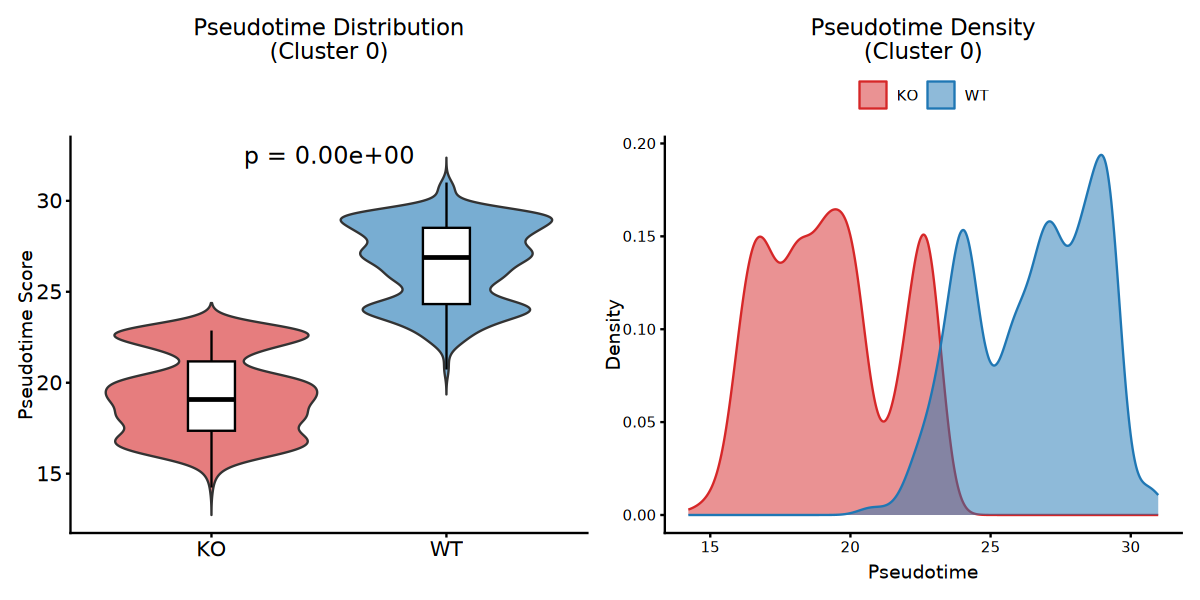

In [6]:
target_clust <- "0" # <--- 请根据实际情况修改这个值，比如 "6", "1", 或 "pDC"

# 生成 Box/Violin Plot
p1 <- plot_pseudotime_comparison(df_all, target_cluster = target_clust)

# 生成 Density Plot
p2 <- plot_pseudotime_density(df_all, target_cluster = target_clust)
# 组合展示
if(!is.null(p1)) {
  options(repr.plot.width = 10, repr.plot.height = 5)
  combined_plot <- p1 + p2
  print(combined_plot)
}

In [7]:
# --- 如果你想批量查看所有 Cluster 的差异 ---
# (可选代码：只打印统计显著性差异大的)
message("\n=== 所有 Cluster 的统计检验结果 ===")
all_clusters <- levels(df_all$Cluster)
stats_results <- data.frame()

for (cls in all_clusters) {
  sub_dat <- subset(df_all, Cluster == cls)
  wt_v <- sub_dat[sub_dat$orig.ident == "WT", "Pseudotime"]
  ko_v <- sub_dat[sub_dat$orig.ident == "KO", "Pseudotime"]
  
  if (length(wt_v) > 5 && length(ko_v) > 5) {
    pval <- wilcox.test(wt_v, ko_v)$p.value
    # 计算均值差
    diff_mean <- mean(ko_v) - mean(wt_v)
    stats_results <- rbind(stats_results, data.frame(Cluster = cls, P_Value = pval, KO_minus_WT_Mean = diff_mean))
  }
}
# 按 P 值排序并显示前5个差异最大的
stats_results <- stats_results[order(stats_results$P_Value), ]
print(head(stats_results, 10))


=== 所有 Cluster 的统计检验结果 ===



   Cluster       P_Value KO_minus_WT_Mean
1        0  0.000000e+00        -7.235704
2        1  0.000000e+00        -8.947960
3        2 1.402539e-260        -4.333446
4        3 4.185237e-256       -15.654852
10       9 4.710492e-110        -9.966002
11      10  3.295963e-93        -3.922589
12      11  1.602769e-73         1.953862
13      12  2.148843e-71        -8.219799
6        5  1.728991e-64        -2.915020
15      14  1.124556e-62        -7.561407


Warning message:
“Using `size` aesthetic for lines was deprecated in
ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


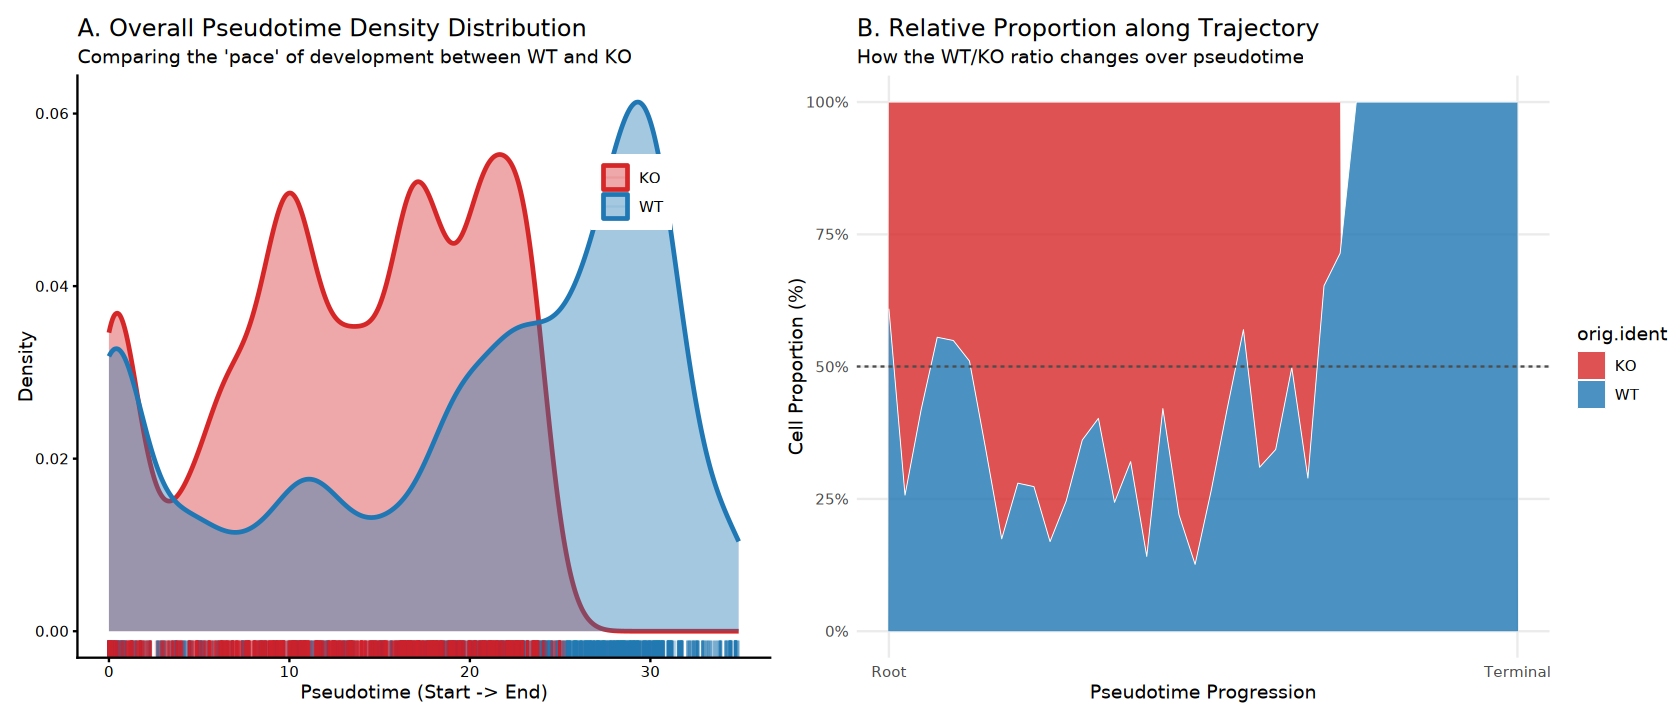

In [8]:
library(ggplot2)
library(dplyr)
library(scales)

# ===================================================================
# 1. 准备绘图数据
# ===================================================================
# 确保使用之前定义的颜色方案
my_colors <- c("WT" = "#1f77b4", "KO" = "#d62728")

# ===================================================================
# 2. 图表 A: 总体密度分布 (Global Density)
# ===================================================================
# 解释: 展示 WT 和 KO 细胞分别主要集中在轨迹的哪个阶段
# 如果 KO 的峰值比 WT 靠右，说明 KO 细胞倾向于堆积在发育晚期；反之则在早期。

p_density <- ggplot(df_all, aes(x = Pseudotime, color = orig.ident, fill = orig.ident)) +
  geom_density(alpha = 0.4, size = 1) + # 绘制密度曲线
  geom_rug(alpha = 0.1) +               # 在底部添加须图，显示真实细胞密度
  scale_fill_manual(values = my_colors) +
  scale_color_manual(values = my_colors) +
  labs(
    title = "A. Overall Pseudotime Density Distribution",
    subtitle = "Comparing the 'pace' of development between WT and KO",
    x = "Pseudotime (Start -> End)",
    y = "Density"
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    legend.position = c(0.8, 0.8), # 把图例放图里面
    legend.title = element_blank()
  )

# ===================================================================
# 3. 图表 B: 沿轨迹的细胞比例变化 (Dynamic Proportion)
# ===================================================================
# 解释: 将轨迹切成 40 段，看每一段里 WT 和 KO 的比例是多少。
# 如果 KO 没有影响，比例应该是一条直线（接近 50/50 或原始细胞数比例）。
# 如果曲线剧烈波动，说明在某个发育时间点发生了阻滞或扩增。

# --- 数据计算 ---
n_bins <- 40 # 将时间轴切分为 40 份
df_all_bin <- df_all %>%
  mutate(bin = cut(Pseudotime, breaks = n_bins)) %>%
  group_by(bin, orig.ident) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(bin) %>%
  mutate(prop = count / sum(count)) %>% # 计算每个 Bin 内的占比
  mutate(bin_time = as.numeric(bin))    # 将因子转为数字以便绘图

# --- 绘图 ---
p_prop <- ggplot(df_all_bin, aes(x = bin_time, y = prop, fill = orig.ident)) +
  # 使用面积图展示比例变化流
  geom_area(alpha = 0.8, color = "white", size = 0.2) + 
  # 添加一条 0.5 的参考线 (假设 WT:KO 投入量是 1:1，如果不是，可忽略此线)
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray30") +
  scale_fill_manual(values = my_colors) +
  scale_x_continuous(breaks = c(1, n_bins), labels = c("Root", "Terminal")) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "B. Relative Proportion along Trajectory",
    subtitle = "How the WT/KO ratio changes over pseudotime",
    x = "Pseudotime Progression",
    y = "Cell Proportion (%)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

# ===================================================================
# 4. 组合并打印
# ===================================================================
options(repr.plot.width = 14, repr.plot.height = 6)
combined_summary <- p_density + p_prop
print(combined_summary)

Warning message in geom_density_ridges(scale = 0.9, alpha = 0.6, rel_min_height = 0.01, :
“Ignoring unknown parameters: `size`”
Picking joint bandwidth of 0.376



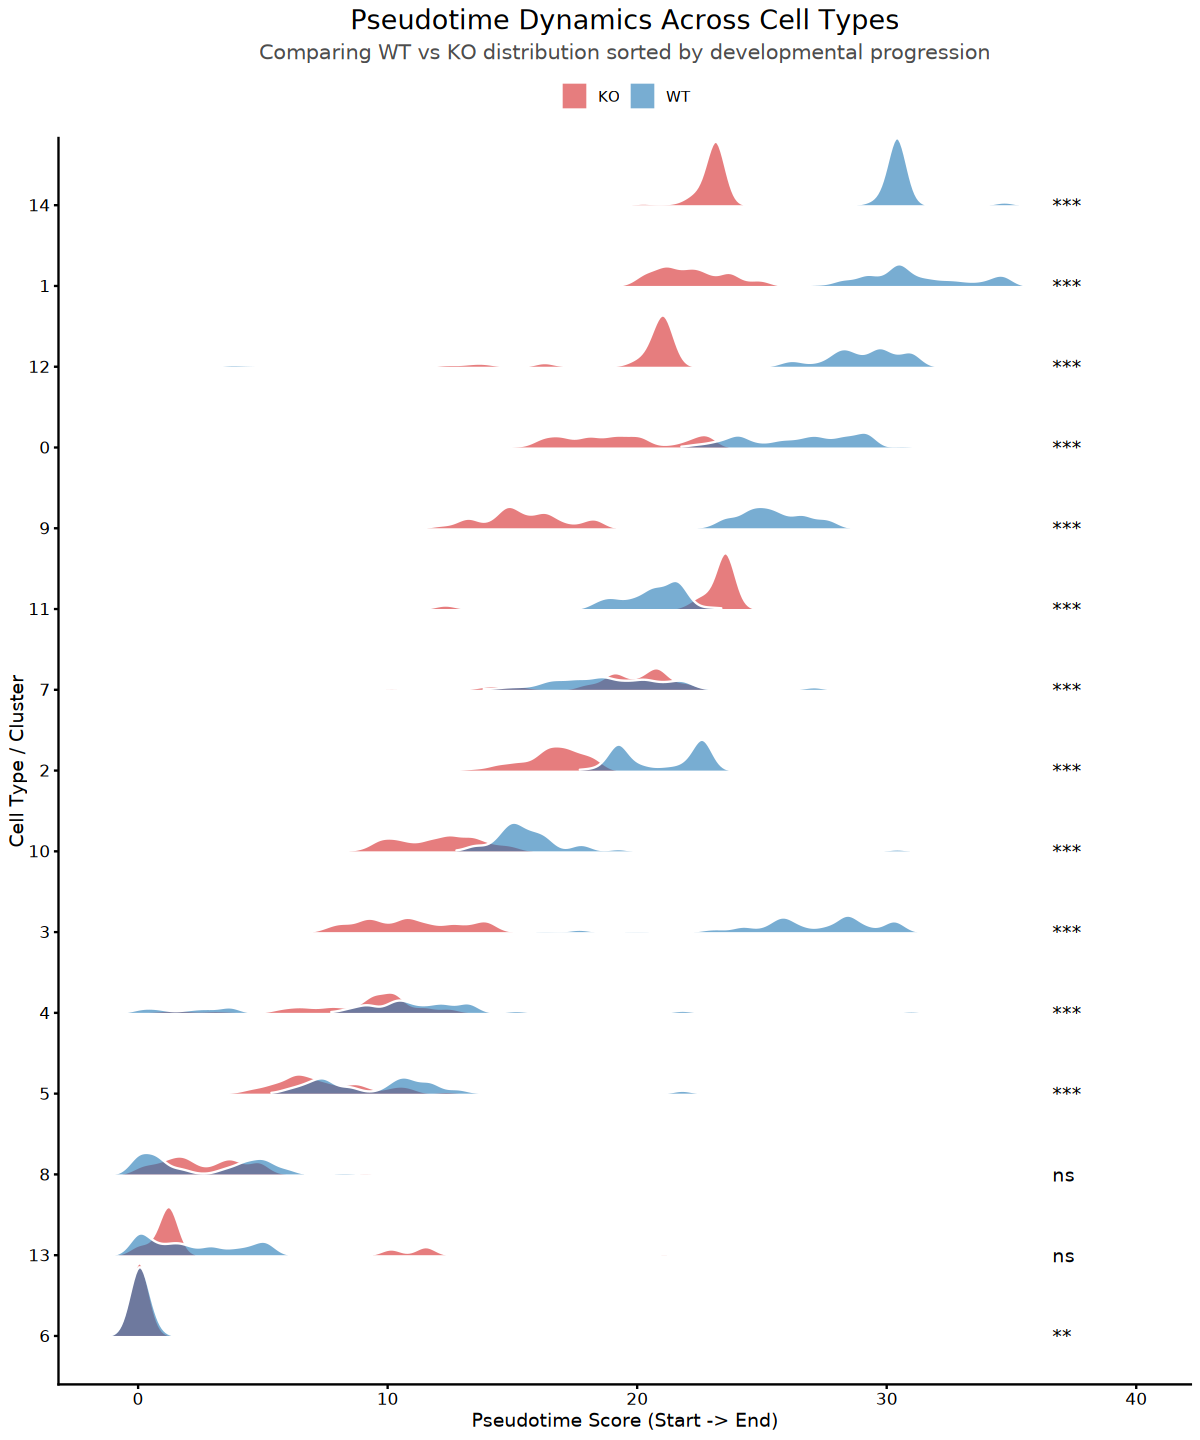

In [9]:
library(ggplot2)
library(dplyr)
library(ggridges) # 必须安装这个包，如果没有请运行 install.packages("ggridges")

# ===================================================================
# 1. 数据准备与排序
# ===================================================================

# 计算每个 Cluster 的 Pseudotime 中位数，用于给 Y 轴排序
# 这样图表会按照发育顺序排列，而不是杂乱无章
cluster_order <- df_all %>%
  group_by(Cluster) %>%
  summarise(median_pt = median(Pseudotime, na.rm = TRUE)) %>%
  arrange(median_pt) %>%
  pull(Cluster)

# 将 Cluster 转为因子，并指定级别顺序
df_all$Cluster <- factor(df_all$Cluster, levels = cluster_order)

# ===================================================================
# 2. 计算统计显著性 (用于标注)
# ===================================================================
stats_df <- data.frame(Cluster = levels(df_all$Cluster), p_label = "", stringsAsFactors = FALSE)

for(i in 1:nrow(stats_df)) {
  cls <- stats_df$Cluster[i]
  sub_dat <- subset(df_all, Cluster == cls)
  
  # 确保两组都有足够的细胞进行检验
  wt_vals <- sub_dat[sub_dat$orig.ident == "WT", "Pseudotime"]
  ko_vals <- sub_dat[sub_dat$orig.ident == "KO", "Pseudotime"]
  
  if(length(wt_vals) > 5 && length(ko_vals) > 5) {
    p_val <- wilcox.test(wt_vals, ko_vals)$p.value
    # 根据 P 值生成星号
    if(p_val < 0.001) {
      stats_df$p_label[i] <- "***"
    } else if(p_val < 0.01) {
      stats_df$p_label[i] <- "**"
    } else if(p_val < 0.05) {
      stats_df$p_label[i] <- "*"
    } else {
      stats_df$p_label[i] <- "ns"
    }
  }
}

# ===================================================================
# 3. 绘制山脊图 (Ridge Plot)
# ===================================================================
# 颜色定义
my_colors <- c("WT" = "#1f77b4", "KO" = "#d62728")

p_ridge <- ggplot(df_all, aes(x = Pseudotime, y = Cluster, fill = orig.ident)) +
  # scale: 控制山峰的高度，<1 分离，>1 重叠。0.9 比较清晰
  geom_density_ridges(scale = 0.9, alpha = 0.6, rel_min_height = 0.01, color = "white", size = 0.2) +
  
  # 颜色设置
  scale_fill_manual(values = my_colors) +
  
  # 添加统计显著性标注 (显示在右侧)
  geom_text(data = stats_df, 
            aes(x = max(df_all$Pseudotime) * 1.05, y = Cluster, label = p_label), 
            inherit.aes = FALSE, hjust = 0, vjust = 0.5, size = 4, color = "black") +
  
  # 坐标轴和标签
  labs(
    title = "Pseudotime Dynamics Across Cell Types",
    subtitle = "Comparing WT vs KO distribution sorted by developmental progression",
    x = "Pseudotime Score (Start -> End)",
    y = "Cell Type / Cluster"
  ) +
  
  # 主题优化
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5, color = "gray30"),
    axis.text.y = element_text(size = 10, face = "bold", color = "black"),
    axis.text.x = element_text(size = 10),
    legend.position = "top",
    legend.title = element_blank()
  ) +
  # 扩展 X 轴右侧空间，防止星号被切掉
  expand_limits(x = max(df_all$Pseudotime) * 1.15)

# ===================================================================
# 4. 打印
# ===================================================================
options(repr.plot.width = 10, repr.plot.height = 12) # 高度设大一点，防止Cluster挤在一起
print(p_ridge)

Warning message in geom_density_ridges(scale = 0.9, alpha = 0.6, rel_min_height = 0.01, :
“Ignoring unknown parameters: `size`”
Picking joint bandwidth of 0.376



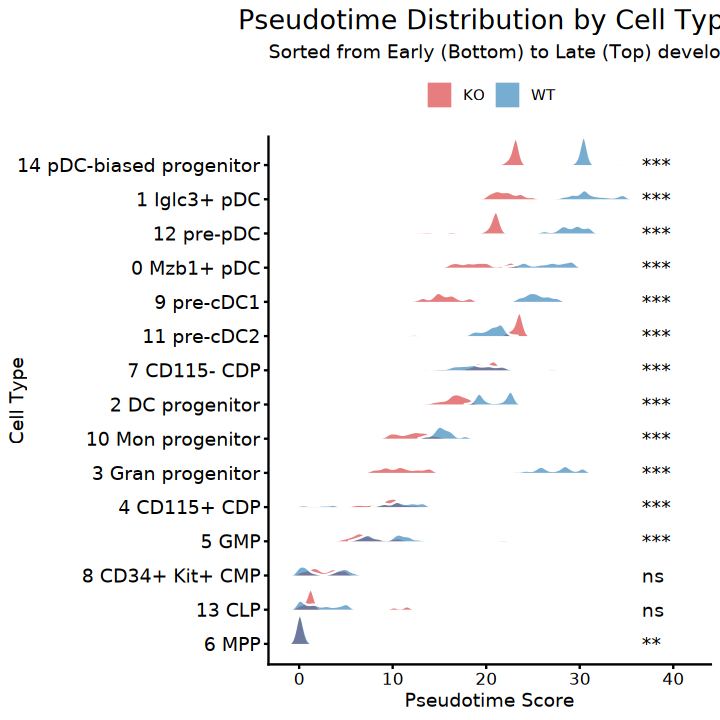

In [15]:
library(ggplot2)
library(dplyr)
library(ggridges)

# ===================================================================
# 1. 重新提取数据 (包含 celltype)
# ===================================================================
# !!! 请注意：将下面的 "cell_type" 替换为你 Seurat 对象中实际存放细胞类型的列名 !!!
# 常见的名字可能是: "celltype", "cell_type", "type", "anno", "major_cell_type"
target_col_name <- "celltype" 

# 检查一下列名是否存在，防止报错
if (!target_col_name %in% names(colData(wt_cds_from_list))) {
  message("警告: 没找到 '", target_col_name, "' 列。")
  message("可用列名如下: ")
  print(names(colData(wt_cds_from_list)))
  stop("请修改代码中的 'target_col_name' 变量为正确的列名！")
}

extract_data_celltype <- function(cds, group_label) {
  pt <- pseudotime(cds)
  meta <- as.data.frame(colData(cds))
  
  df <- data.frame(
    Barcode = rownames(meta),
    Pseudotime = pt,
    orig.ident = group_label,
    celltype = meta[[target_col_name]] # 提取细胞类型
  )
  return(df)
}

# 提取并合并
df_wt_ct <- extract_data_celltype(wt_cds_from_list, "WT")
df_ko_ct <- extract_data_celltype(ko_cds_from_list, "KO")
df_all_ct <- rbind(df_wt_ct, df_ko_ct)

# 过滤数据
df_all_ct <- df_all_ct[is.finite(df_all_ct$Pseudotime), ] # 去除无 Pseudotime 的细胞
df_all_ct <- df_all_ct[!is.na(df_all_ct$celltype), ]      # 去除无注释的细胞

# ===================================================================
# 2. 排序 (关键步骤)
# ===================================================================
# 计算每个 celltype 的 Pseudotime 中位数，并按从小到大排序
# 这样图表底部是“起点”细胞，顶部是“终点”细胞
type_order <- df_all_ct %>%
  group_by(celltype) %>%
  summarise(median_pt = median(Pseudotime, na.rm = TRUE)) %>%
  arrange(median_pt) %>%
  pull(celltype)

# 设置因子水平
df_all_ct$celltype <- factor(df_all_ct$celltype, levels = type_order)

# ===================================================================
# 3. 计算统计显著性
# ===================================================================
stats_ct <- data.frame(celltype = levels(df_all_ct$celltype), p_label = "", stringsAsFactors = FALSE)

for(i in 1:nrow(stats_ct)) {
  ct <- stats_ct$celltype[i]
  sub_dat <- subset(df_all_ct, celltype == ct)
  
  wt_vals <- sub_dat[sub_dat$orig.ident == "WT", "Pseudotime"]
  ko_vals <- sub_dat[sub_dat$orig.ident == "KO", "Pseudotime"]
  
  if(length(wt_vals) > 5 && length(ko_vals) > 5) {
    p_val <- wilcox.test(wt_vals, ko_vals)$p.value
    if(p_val < 0.001) {
      stats_ct$p_label[i] <- "***"
    } else if(p_val < 0.01) {
      stats_ct$p_label[i] <- "**"
    } else if(p_val < 0.05) {
      stats_ct$p_label[i] <- "*"
    } else {
      stats_ct$p_label[i] <- "ns"
    }
  }
}

my_colors <- c("WT" = "#8abbf9", "KO" = "#D62728")

p_ridge_ct <- ggplot(df_all_ct, aes(x = Pseudotime, y = celltype, fill = orig.ident)) +
  
  # ==========================================================
  # !!! 核心修改部分 !!!
  # ==========================================================
  geom_density_ridges(
    scale = 1.2,           # 1. 把山峰放大一点 (原0.9 -> 1.2)，显得更饱满
    alpha = 0.85,          # 2. 提高不透明度 (原0.6 -> 0.85)，颜色更实
    color = "black",       # 3. 边框改成黑色 (原 white)，通过描边突出主体
    size = 0.4,            # 4. 边框线条加粗 (原0.2 -> 0.4)
    rel_min_height = 0.01  # 忽略极低值
  ) +
  # ==========================================================
  
  scale_fill_manual(values = my_colors) +
  
  # 标注星号 (保持不变)
  geom_text(data = stats_ct, 
            aes(x = max(df_all_ct$Pseudotime) * 1.05, y = celltype, label = p_label), 
            inherit.aes = FALSE, hjust = 0, vjust = 0.5, size = 5, fontface = "bold") + # 字号加大一点
  
  labs(
    title = "Pseudotime Distribution by Cell Type",
    subtitle = "WT vs KO distribution along developmental trajectory",
    x = "Pseudotime Score",
    y = "" # 去掉Y轴标题，因为标签本身就很清楚
  ) +
  
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
    axis.text.y = element_text(size = 12, face = "bold", color = "black"), # Y轴文字加黑加粗
    axis.text.x = element_text(size = 12, color = "black"),
    axis.line = element_line(size = 0.8), # 坐标轴线加粗
    legend.position = "top",
    legend.text = element_text(size = 12),
    legend.title = element_blank()
  ) +
  expand_limits(x = max(df_all_ct$Pseudotime) * 1.2)
options(repr.plot.width = 9, repr.plot.height = 9)
print(p_ridge_ct)

Warning message in geom_density_ridges(scale = 1.2, alpha = 0.85, color = "black", :
“Ignoring unknown parameters: `size`”
Picking joint bandwidth of 0.376



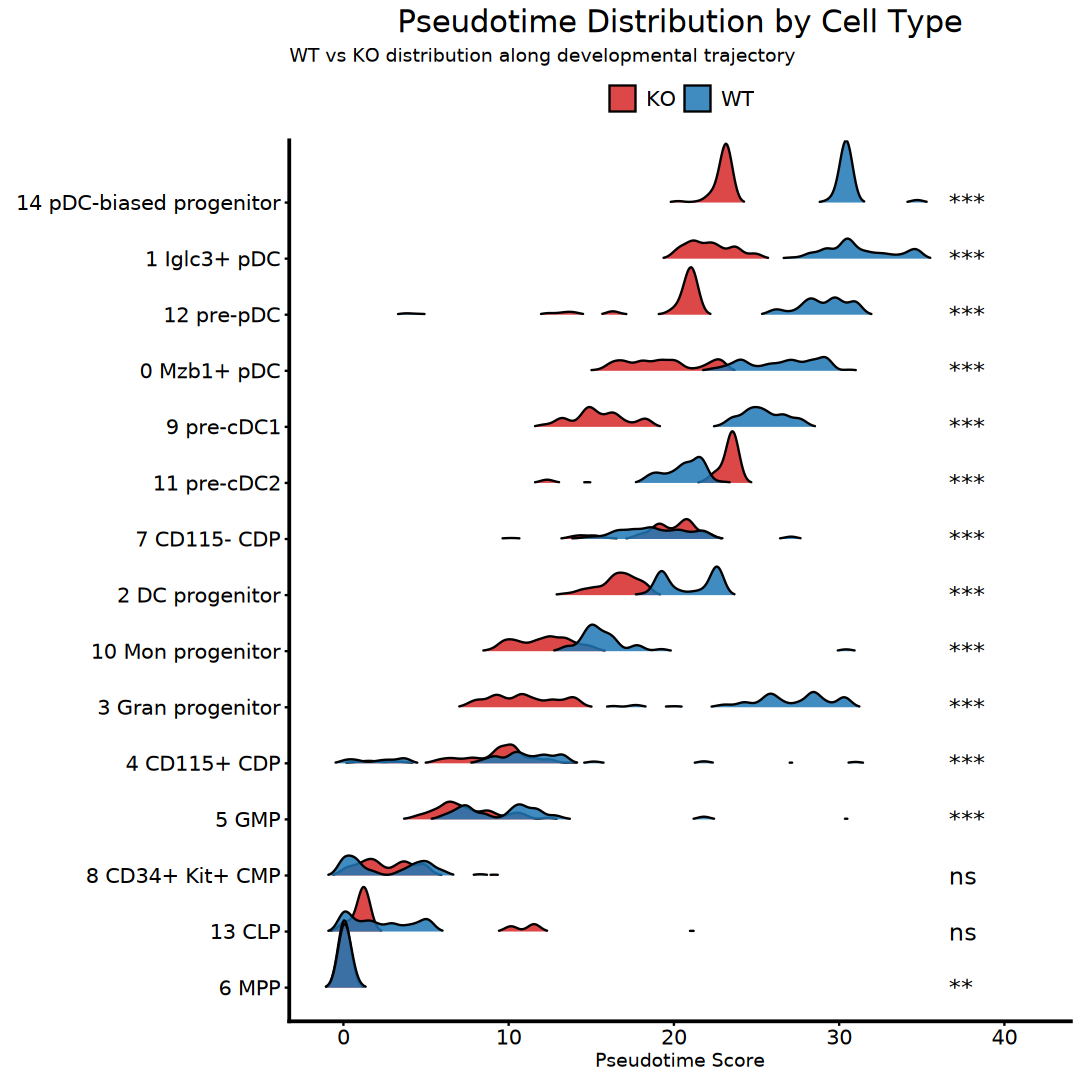

In [19]:
library(ggplot2)
library(ggridges)

# 定义颜色 (建议使用稍微深一点的颜色，或者保持原样配合黑色边框)
# 如果觉得原色不够深，可以尝试这一组高对比度配色：
# WT (深蓝): "#005f9e", KO (深红): "#c1272d"
my_colors <- c("WT" = "#1f77b4", "KO" = "#d62728")

p_ridge_ct <- ggplot(df_all_ct, aes(x = Pseudotime, y = celltype, fill = orig.ident)) +
  
  # ==========================================================
  # !!! 核心修改部分 !!!
  # ==========================================================
  geom_density_ridges(
    scale = 1.2,           # 1. 把山峰放大一点 (原0.9 -> 1.2)，显得更饱满
    alpha = 0.85,          # 2. 提高不透明度 (原0.6 -> 0.85)，颜色更实
    color = "black",       # 3. 边框改成黑色 (原 white)，通过描边突出主体
    size = 0.4,            # 4. 边框线条加粗 (原0.2 -> 0.4)
    rel_min_height = 0.01  # 忽略极低值
  ) +
  # ==========================================================
  
  scale_fill_manual(values = my_colors) +
  
  # 标注星号 (保持不变)
  geom_text(data = stats_ct, 
            aes(x = max(df_all_ct$Pseudotime) * 1.05, y = celltype, label = p_label), 
            inherit.aes = FALSE, hjust = 0, vjust = 0.5, size = 5, fontface = "bold") + # 字号加大一点
  
  labs(
    title = "Pseudotime Distribution by Cell Type",
    subtitle = "WT vs KO distribution along developmental trajectory",
    x = "Pseudotime Score",
    y = "" # 去掉Y轴标题，因为标签本身就很清楚
  ) +
  
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
    axis.text.y = element_text(size = 12, face = "bold", color = "black"), # Y轴文字加黑加粗
    axis.text.x = element_text(size = 12, color = "black"),
    axis.line = element_line(size = 0.8), # 坐标轴线加粗
    legend.position = "top",
    legend.text = element_text(size = 12),
    legend.title = element_blank()
  ) +
  expand_limits(x = max(df_all_ct$Pseudotime) * 1.2)
options(repr.plot.width = 9, repr.plot.height = 9)
print(p_ridge_ct)

In [20]:
# --- 1. 定义感兴趣的基因 ---
# 比如 pDC 发育的关键基因：Irf8, Tcf4, Runx2, SpiB 等
genes_of_interest <- c("Irf8", "Tcf4", "Bcl11a", "Runx2") 

# --- 2. 提取数据并准备绘图 ---
# Monocle3 自带 plot_genes_in_pseudotime，但我们想要分 WT/KO 画线，
# 最好提取数据用 ggplot2 自己画，或者利用自带函数的 color_cells_by 参数

subset_cds <- wt_cds_from_list[rowData(wt_cds_from_list)$gene_short_name %in% genes_of_interest, ]
# 为了对比，这里其实应该用合并后的对象 (如果之前没合并，建议创建一个包含 WT 和 KO 的大 CDS 对象用于画图)
# 假设你有一个合并后的 cds 对象叫 combined_cds

plot_genes_in_pseudotime(combined_cds[rowData(combined_cds)$gene_short_name %in% genes_of_interest,],
                         color_cells_by = "orig.ident", # 按 WT/KO 上色
                         min_expr = 0.5) +
  scale_color_manual(values = c("WT" = "#1f77b4", "KO" = "#d62728")) +
  theme_minimal()

ERROR: Error: object 'combined_cds' not found


In [23]:
library(monocle3)
library(ggplot2)
library(dplyr)

# 1. 使用 monocle3 自带的 combine_cds 函数合并
message("正在合并 WT 和 KO 对象...")
combined_cds <- combine_cds(list(wt_cds_from_list, ko_cds_from_list))

# 2. 将之前分开计算的 Pseudotime 合并并添加到新对象的 colData 中
# 注意：直接合并后的对象是没有 pseudotime 的，必须手动加进去
pt_wt <- pseudotime(wt_cds_from_list)
pt_ko <- pseudotime(ko_cds_from_list)

# 确保名字匹配 (combine_cds 会保留原来的 barcode)
pt_all <- c(pt_wt, pt_ko)
# 只保留 combined_cds 中存在的细胞 (以防万一)
pt_all <- pt_all[colnames(combined_cds)]

# 将拟时序存入 colData 的特定列，方便后续调用
colData(combined_cds)$monocle3_pseudotime <- pt_all

message("combined_cds 创建完成！")

正在合并 WT 和 KO 对象...



Warning message in new_cell_data_set(all_exp, cell_metadata = all_pd, gene_metadata = all_fd):
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
combined_cds 创建完成！



`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


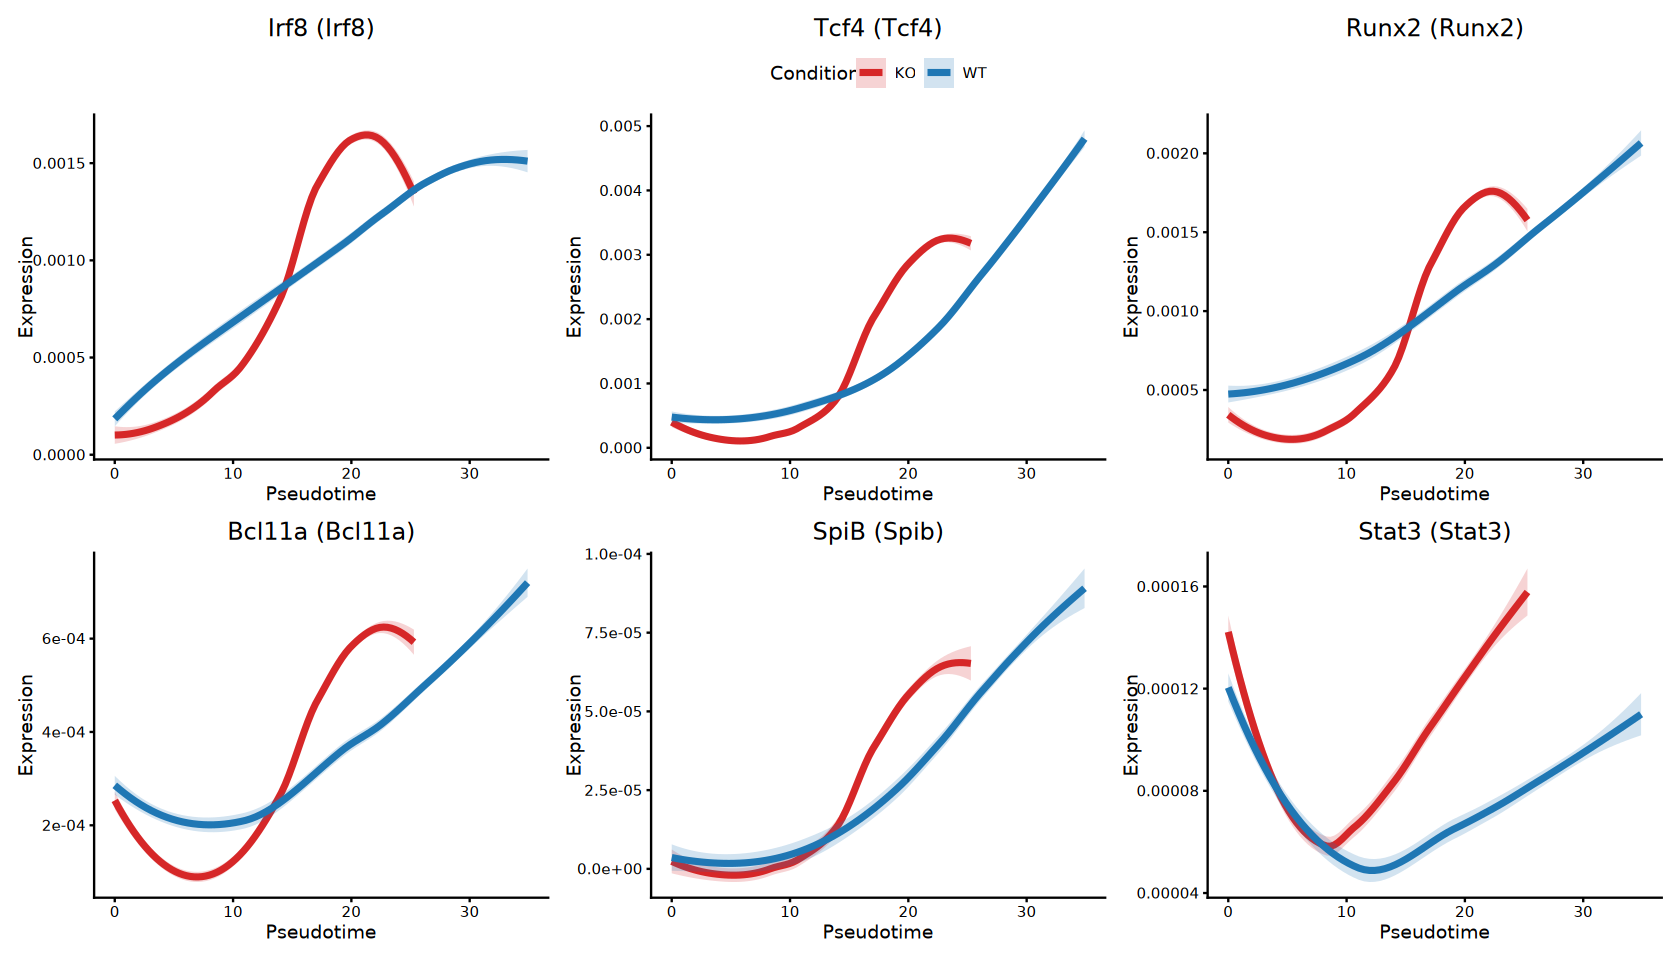

In [26]:
library(monocle3)
library(ggplot2)
library(dplyr)
library(patchwork)

# 重新提取对象
wt_cds <- cds_list_loaded$WT
ko_cds <- cds_list_loaded$KO

# =================================================================
# 智能查找基因 ID 函数
# =================================================================
find_gene_id_robust <- function(cds, gene_name) {
  # 1. 直接匹配 rownames (精确匹配)
  if (gene_name %in% rownames(cds)) return(gene_name)
  
  # 2. 尝试匹配 rowData 中的 gene_short_name (如果有这一列)
  rdata <- rowData(cds)
  if ("gene_short_name" %in% colnames(rdata)) {
    match_idx <- which(rdata$gene_short_name == gene_name)
    if (length(match_idx) > 0) return(rownames(cds)[match_idx[1]])
  }
  
  # 3. 忽略大小写匹配 rownames
  match_idx <- grep(paste0("^", gene_name, "$"), rownames(cds), ignore.case = TRUE)
  if (length(match_idx) > 0) return(rownames(cds)[match_idx[1]])
  
  # 4. 忽略大小写匹配 gene_short_name
  if ("gene_short_name" %in% colnames(rdata)) {
    match_idx <- grep(paste0("^", gene_name, "$"), rdata$gene_short_name, ignore.case = TRUE)
    if (length(match_idx) > 0) return(rownames(cds)[match_idx[1]])
  }
  
  return(NULL) # 实在找不到
}

# =================================================================
# 绘图数据提取函数
# =================================================================
get_gene_data_robust <- function(cds, gene_name, group_label) {
  # 智能查找真实 ID
  real_id <- find_gene_id_robust(cds, gene_name)
  
  if (is.null(real_id)) {
    warning(paste("Gene", gene_name, "not found in", group_label))
    return(NULL)
  }
  
  # 提取数据
  expr_vals <- as.numeric(normalized_counts(cds)[real_id, ])
  pt_vals <- pseudotime(cds)
  
  df <- data.frame(
    Barcode = colnames(cds),
    Expression = expr_vals,
    Pseudotime = pt_vals,
    Condition = group_label,
    RealName = real_id # 记录一下找到的真实名字
  )
  df <- df[is.finite(df$Pseudotime), ]
  return(df)
}

# =================================================================
# 绘图主函数
# =================================================================
plot_comparison_curve <- function(gene_name) {
  df_wt <- get_gene_data_robust(wt_cds, gene_name, "WT")
  df_ko <- get_gene_data_robust(ko_cds, gene_name, "KO")
  
  plot_df <- rbind(df_wt, df_ko)
  
  if (is.null(plot_df) || nrow(plot_df) == 0) {
    message(paste("Skipping plotting for", gene_name, "- no data found."))
    return(NULL) # 返回空，不报错
  }
  
  # 打印一下找到的真实基因名，方便你确认
  found_name <- unique(plot_df$RealName)[1]
  
  p <- ggplot(plot_df, aes(x = Pseudotime, y = Expression, color = Condition, fill = Condition)) +
    geom_smooth(method = "loess", span = 0.8, size = 1.5, se = TRUE, alpha = 0.2) +
    scale_color_manual(values = c("WT" = "#1f77b4", "KO" = "#d62728")) +
    scale_fill_manual(values = c("WT" = "#1f77b4", "KO" = "#d62728")) +
    labs(
      title = paste0(gene_name, " (", found_name, ")"),
      x = "Pseudotime",
      y = "Expression"
    ) +
    theme_classic() +
    theme(
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
      legend.position = "none" # 拼图时隐藏图例，最后统一加
    )
  return(p)
}

# =================================================================
# 执行
# =================================================================
# 你之前的列表，我把大小写都列上，总有一个能中
target_genes <- c("Irf8", "Tcf4", "Runx2", "Bcl11a", "SpiB", "Stat3")

plot_list <- list()
for (g in target_genes) {
  res <- plot_comparison_curve(g)
  if (!is.null(res)) plot_list[[g]] <- res
}

if (length(plot_list) > 0) {
  options(repr.plot.width = 14, repr.plot.height = 8)
  print(wrap_plots(plot_list, ncol = 3) + plot_layout(guides = "collect") & theme(legend.position = "top"))
} else {
  message("仍然没有找到任何基因，请务必检查第一步的输出结果！")
}

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.5 GiB”
Scanning 500 genes for differential patterns...


=== Top 10 导致轨迹差异的潜在基因 ===



                 gene      slope_wt      slope_ko   diff_score
Pseudotime     Tmsb4x  6.975183e-05  1.218039e-04 5.205210e-05
Pseudotime2      Tcf4  1.151148e-04  1.571252e-04 4.201037e-05
Pseudotime13     Irf8  4.233652e-05  8.051445e-05 3.817793e-05
Pseudotime3      Ptma -3.030885e-05 -6.758673e-05 3.727788e-05
Pseudotime4     Runx2  4.589566e-05  8.116049e-05 3.526483e-05
Pseudotime40     Rps2 -2.157074e-05 -5.445311e-05 3.288237e-05
Pseudotime82 Hsp90ab1 -1.893986e-05 -5.135836e-05 3.241850e-05
Pseudotime39    Rplp1 -1.816006e-05 -4.921919e-05 3.105913e-05
Pseudotime32    Rps12 -2.550200e-05 -5.627430e-05 3.077230e-05
Pseudotime61    Prtn3 -1.216235e-05 -4.206725e-05 2.990490e-05


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


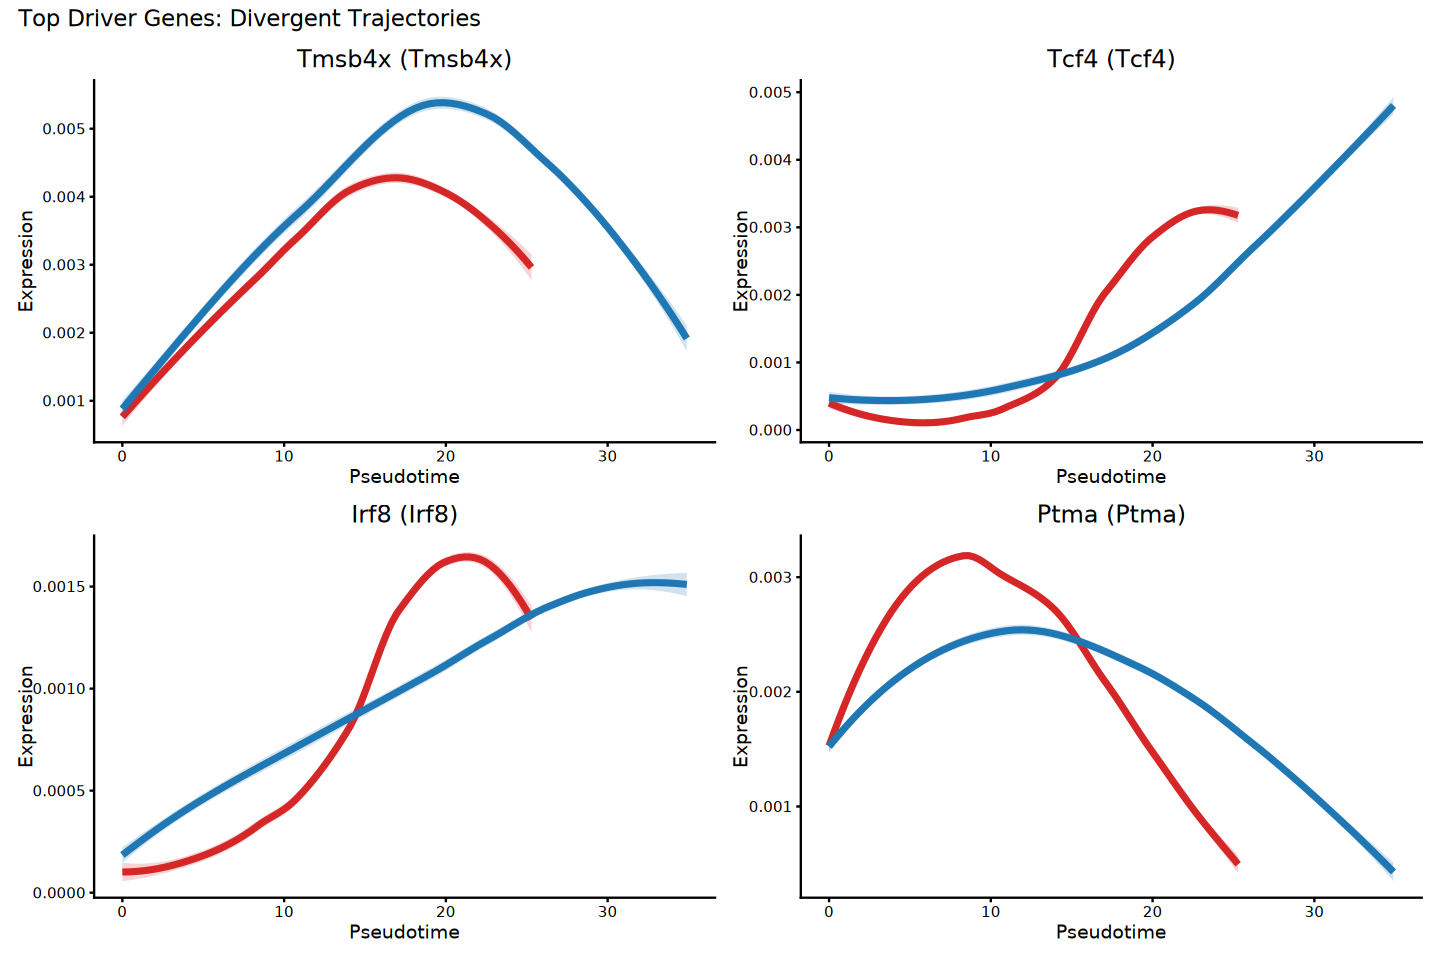

In [27]:
# 这一步计算量稍大，会筛选 Top 基因
find_diff_drivers <- function(gene_subset = NULL) {
  
  # 如果不指定基因，就用高变基因 (节省时间)
  if(is.null(gene_subset)) {
    # 简单的取 variance 最大的前 500 个基因
    mat <- normalized_counts(wt_cds)
    vars <- apply(mat, 1, var)
    gene_subset <- names(sort(vars, decreasing = TRUE))[1:500]
  }
  
  results <- data.frame()
  
  message(paste("Scanning", length(gene_subset), "genes for differential patterns..."))
  
  for(g in gene_subset) {
    # 提取数据
    df_wt <- get_gene_data_robust(wt_cds, g, "WT")
    df_ko <- get_gene_data_robust(ko_cds, g, "KO")
    
    if(!is.null(df_wt) && !is.null(df_ko) && nrow(df_wt)>10 && nrow(df_ko)>10) {
      # 简单的线性模型：Expression ~ Pseudotime
      # 我们比较 WT 和 KO 的回归斜率 (Slope) 差异
      m_wt <- lm(Expression ~ Pseudotime, data = df_wt)
      m_ko <- lm(Expression ~ Pseudotime, data = df_ko)
      
      slope_wt <- coef(m_wt)[2]
      slope_ko <- coef(m_ko)[2]
      
      # 计算差异分数：斜率差的绝对值 + 平均表达量差
      diff_score <- abs(slope_wt - slope_ko)
      
      results <- rbind(results, data.frame(
        gene = g,
        slope_wt = slope_wt,
        slope_ko = slope_ko,
        diff_score = diff_score
      ))
    }
  }
  
  return(results[order(results$diff_score, decreasing = TRUE), ])
}

# 运行筛选 (自动使用上面 Top 500 高变基因)
driver_res <- find_diff_drivers()

message("\n=== Top 10 导致轨迹差异的潜在基因 ===")
print(head(driver_res, 10))

# 画出 Top 4 最具差异的基因
top_drivers <- head(driver_res$gene, 4)
plot_list_drivers <- list()
for (g in top_drivers) {
  plot_list_drivers[[g]] <- plot_comparison_curve(g)
}

if (length(plot_list_drivers) > 0) {
  options(repr.plot.width = 12, repr.plot.height = 8)
  print(wrap_plots(plot_list_drivers, ncol = 2) + 
        plot_annotation(title = "Top Driver Genes: Divergent Trajectories"))
}

Warning message in geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8):
“Ignoring unknown parameters: `size`”
Warning message in geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8):
“Ignoring unknown parameters: `size`”
Warning message in geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8):
“Ignoring unknown parameters: `size`”
Warning message in geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8):
“Ignoring unknown parameters: `size`”
Warning message in geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8):
“Ignoring unknown parameters: `size`”
Warning message in geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8):
“Ignoring unknown parameters: `size`”


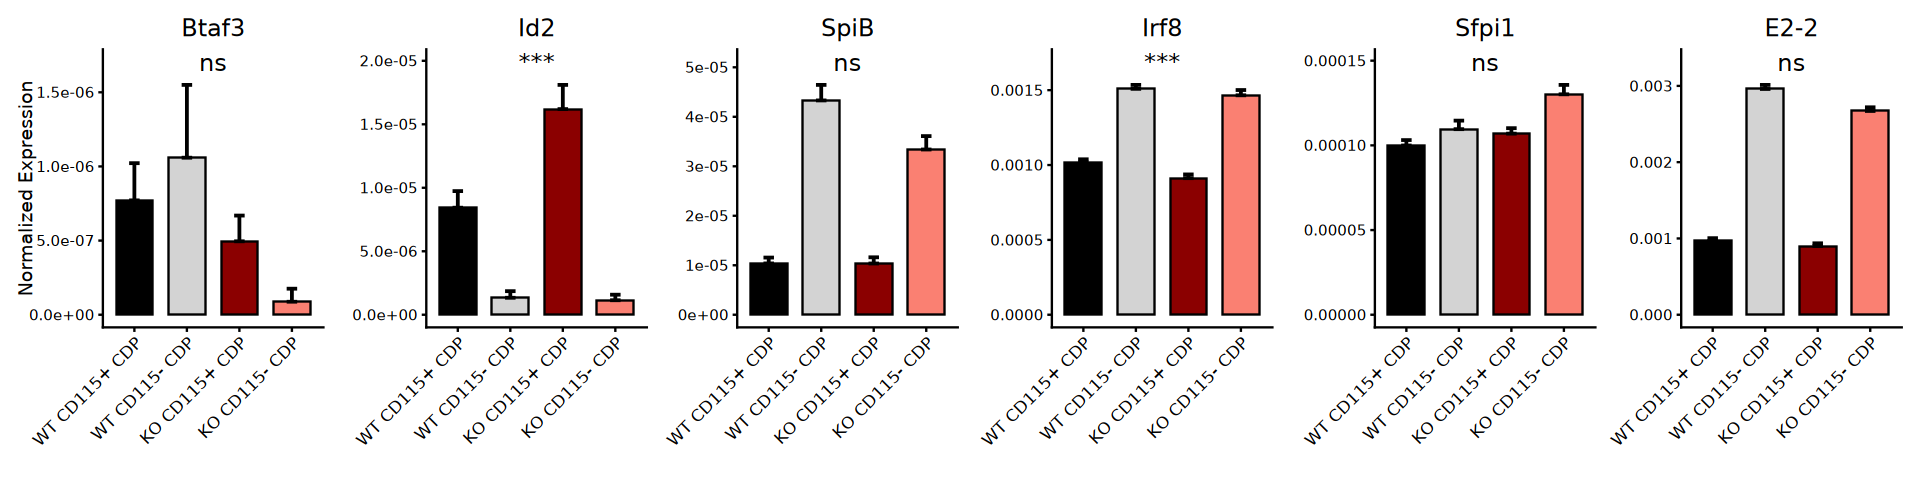

In [28]:
library(monocle3)
library(ggplot2)
library(dplyr)
library(ggpubr) # 用于添加统计检验 p 值

# =================================================================
# 1. 定义基因映射和目标 Cluster
# =================================================================
# 基因映射 (显示名 = 真实名)
# 请确保真实名(右边)是你数据里实际的 Gene Symbol
gene_map <- c(
  "Btaf3" = "Batf3",
  "Id2"   = "Id2",
  "SpiB"  = "Spib",  # 注意大小写，如果是小鼠通常是首字母大写
  "Irf8"  = "Irf8",
  "Sfpi1" = "Spi1",  # PU.1
  "E2-2"  = "Tcf4"   # E2-2
)

# 目标 Cluster (必须与你 seurat/monocle 对象里的名字完全一致)
# 假设你的 celltype 列叫 "cell_type" 或 "RNA_snn_res.0.8" 对应的名字
target_clusters <- c("4 CD115+ CDP", "7 CD115- CDP") 
# 如果你的数据里名字不一样，请在这里修改！例如: c("CDP_1", "CDP_2")

# =================================================================
# 2. 数据提取函数
# =================================================================
# 还是分别处理 WT 和 KO，比较稳健
wt_cds <- cds_list_loaded$WT
ko_cds <- cds_list_loaded$KO

extract_expression_data <- function(cds, group_label) {
  # 1. 提取元数据
  meta <- as.data.frame(colData(cds))
  
  # !!! 请确认你的细胞类型列名 !!!
  # 这里假设是 "cell_type"，如果是别的(如 active.ident)，请修改
  # 如果之前没有把 celltype 存进 colData，你需要先存进去
  # meta$cell_type <- ... 
  
  # 假设我们用之前提到的 "Cluster" 列作为细胞类型来源
  # 这里为了演示，假设你已经有了叫 'celltype' 的列
  # 如果没有，请把下面这行改为实际列名
  if(!"celltype" %in% colnames(meta)) {
     # 尝试自动修正: 如果有 RNA_snn_res.0.8 就用它
     if("RNA_snn_res.0.8" %in% colnames(meta)) {
       meta$celltype <- meta$RNA_snn_res.0.8 
     } else {
       stop("请在 colData 中找到存放细胞类型的列名，并修改代码！")
     }
  }

  # 2. 筛选目标细胞
  target_cells <- rownames(meta)[meta$celltype %in% target_clusters]
  if(length(target_cells) == 0) return(NULL)
  
  # 3. 提取表达矩阵 (只取需要的基因)
  # 智能查找基因名 (复用之前的 robust 逻辑或直接取)
  valid_genes <- gene_map[gene_map %in% rownames(cds) | gene_map %in% rowData(cds)$gene_short_name]
  
  # 找到对应的 ID
  gene_ids <- character()
  for(g in valid_genes) {
    if(g %in% rownames(cds)) {
      gene_ids[g] <- g
    } else {
      # 尝试在 rowData 找
      rid <- rownames(subset(rowData(cds), gene_short_name == g))
      if(length(rid) > 0) gene_ids[g] <- rid[1]
    }
  }
  
  if(length(gene_ids) == 0) return(NULL)

  expr_mat <- as.matrix(normalized_counts(cds)[gene_ids, target_cells])
  
  # 4. 构建长数据框
  df_list <- list()
  for(display_n in names(gene_map)) {
    real_n <- gene_map[[display_n]]
    if(real_n %in% names(gene_ids)) {
      gid <- gene_ids[[real_n]]
      vals <- expr_mat[gid, ]
      
      # 构建分组 Group: WT CD115+ CDP 等
      cell_types <- meta[names(vals), "celltype"]
      
      # 简单的字符串匹配构建 Group
      groups <- ifelse(grepl("CD115\\+", cell_types), paste(group_label, "CD115+ CDP"),
                ifelse(grepl("CD115-", cell_types), paste(group_label, "CD115- CDP"), "Other"))
      
      df_list[[display_n]] <- data.frame(
        Expression = vals,
        Group = groups,
        Gene_Display = display_n,
        Condition = group_label
      )
    }
  }
  
  return(do.call(rbind, df_list))
}

# =================================================================
# 3. 提取并合并数据
# =================================================================
df_wt <- extract_expression_data(wt_cds, "WT")
df_ko <- extract_expression_data(ko_cds, "KO")
df_all <- rbind(df_wt, df_ko)

# 过滤掉 Other
df_all <- df_all[df_all$Group != "Other", ]

# 设置 Group 的因子顺序，保证画图顺序一致
group_order <- c("WT CD115+ CDP", "WT CD115- CDP", "KO CD115+ CDP", "KO CD115- CDP")
df_all$Group <- factor(df_all$Group, levels = group_order)

# =================================================================
# 4. 绘图 (完全复刻 Python 风格)
# =================================================================
# 颜色映射
my_colors <- c(
  "WT CD115+ CDP" = "#000000", 
  "WT CD115- CDP" = "#D3D3D3", 
  "KO CD115+ CDP" = "#8B0000", 
  "KO CD115- CDP" = "#FA8072"
)

# 循环画每个基因，最后拼图
plot_list <- list()

for (g_disp in names(gene_map)) {
  # 筛选当前基因数据
  sub_df <- subset(df_all, Gene_Display == g_disp)
  
  if(nrow(sub_df) > 0) {
    # 统计检验 (WT+ vs KO+)
    wt_pos <- sub_df$Expression[sub_df$Group == "WT CD115+ CDP"]
    ko_pos <- sub_df$Expression[sub_df$Group == "KO CD115+ CDP"]
    
    p_label <- "ns"
    if(length(wt_pos)>0 && length(ko_pos)>0) {
      pval <- wilcox.test(wt_pos, ko_pos)$p.value
      if(pval < 0.001) p_label <- "***"
      else if(pval < 0.01) p_label <- "**"
      else if(pval < 0.05) p_label <- "*"
    }
    
    # 汇总数据画 Barplot (Mean + SE)
    summary_df <- sub_df %>%
      group_by(Group) %>%
      summarise(
        mean = mean(Expression),
        se = sd(Expression) / sqrt(n())
      )
    
    p <- ggplot(summary_df, aes(x = Group, y = mean, fill = Group)) +
      # 柱状图
      geom_bar(stat = "identity", color = "black", width = 0.7, size = 0.8) +
      # 误差棒
      geom_errorbar(aes(ymin = mean, ymax = mean + se), width = 0.2, size = 0.8) +
      
      # 颜色
      scale_fill_manual(values = my_colors) +
      
      # 标题和标签
      labs(title = g_disp, y = ifelse(g_disp == names(gene_map)[1], "Normalized Expression", ""), x = "") +
      
      # 添加 P 值 (手动添加在图上方)
      annotate("text", x = 2.5, y = max(summary_df$mean + summary_df$se) * 1.1, 
               label = p_label, size = 5) +
      
      # 主题
      theme_classic() +
      theme(
        plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1, size = 10, color="black"),
        legend.position = "none"
      )
    
    plot_list[[g_disp]] <- p
  }
}

# 拼图
library(patchwork)
options(repr.plot.width = 16, repr.plot.height = 4)
wrap_plots(plot_list, nrow = 1)

In [29]:
# =================================================================
# 使用 Monocle3 fit_models 进行严格的统计检验
# =================================================================

# 1. 挑选一些你感兴趣的基因 (或者用 graph_test 筛选出的 Top 基因)
# 为了演示速度，我们只测这几个关键基因，全基因组跑会很慢
target_genes_list <- c("Irf8", "Tcf4", "Runx2", "Bcl11a", "SpiB")
gene_ids <- row.names(subset(rowData(combined_cds), gene_short_name %in% target_genes_list))

subset_cds <- combined_cds[gene_ids, ]

# 2. 构建模型公式
# "~ monocle3_pseudotime * orig.ident" 的意思是：
# 基因表达 ~ 时间 + 基因型 + (时间 x 基因型)
# 如果 (时间 x 基因型) 显著，说明 WT 和 KO 的轨迹斜率不同
model_formula <- "~monocle3_pseudotime * orig.ident"

message("正在进行 GLM 模型拟合 (这可能需要一点时间)...")
gene_fits <- fit_models(subset_cds, model_formula_str = model_formula)

# 3. 提取结果表
fit_coefs <- coefficient_table(gene_fits)

# 4. 筛选我们要看的 "交互项" (Interaction Term)
# 这里的 term 名字通常是 "monocle3_pseudotime:orig.identWT" 或类似
# 意思是：WT 相对于 KO，在时间斜率上的差异
interaction_results <- fit_coefs %>% 
  filter(grepl(":", term)) %>% # 筛选包含冒号的行 (交互项)
  select(gene_short_name, term, q_value, estimate) %>%
  arrange(q_value)

message("\n=== 统计检验结果：WT 与 KO 的轨迹差异显著性 ===")
print(interaction_results)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function '%in%': object 'gene_short_name' not found
